In [1]:
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np

from albumentations.pytorch import ToTensorV2
from skimage.morphology import dilation, disk

from helpy.helpy import *
from helpy.helpy_visualize import *
from helpy.helpy_calculate import *
from TMJDataset import TMJDataset

In [2]:
rename_files_and_update_annotations(folder_path="special_dataset")
save_coco_masks_npy(
    coco_annotation_path="special_dataset/annotations.json",
    output_dir="special_dataset/masks"
)

Файл special_dataset_00000.jpg не найден
Файл special_dataset_00001.jpg не найден
Файл special_dataset_00002.jpg не найден
Маски сохранены в special_dataset/masks в формате .npy


In [3]:
transforms = A.Compose([
    ToTensorV2(),
])
dataset = TMJDataset(
    image_dir="special_dataset/images",
    mask_dir="special_dataset/masks",
    transforms=transforms
)

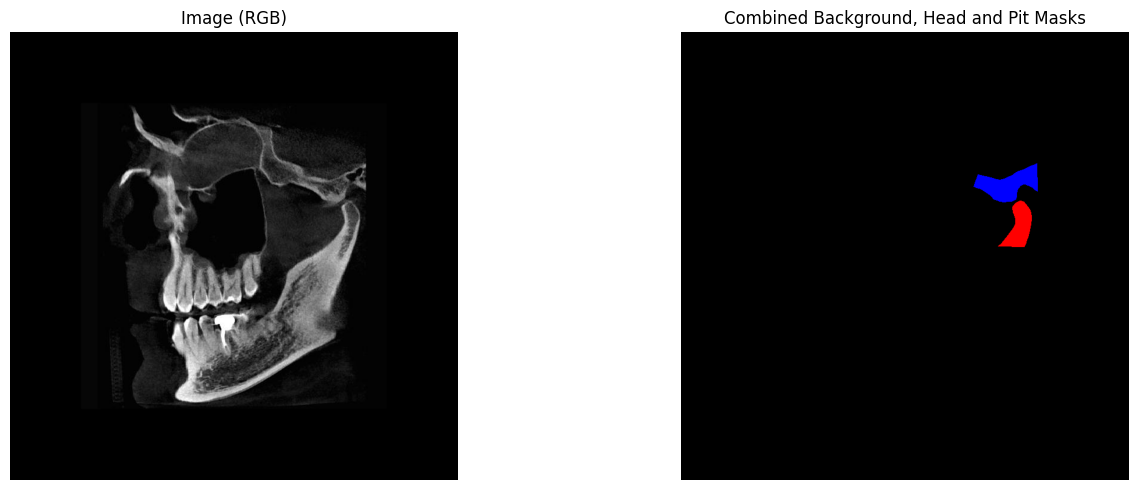

In [4]:
dataset.visualize(idx=1)

In [5]:
image, mask_tensor = dataset[1]
areas = calculate_areas(mask_tensor)
scaled_mask = scale_head_mask(mask_tensor)
top_point, right_point, left_point = find_key_points(mask=scaled_mask, use_avarage=True)
top_left_point = tuple([105, 61])
x, y = top_point[0], right_point[1]
print(f'Верхняя точка = ({top_point[0]}, {top_point[1]})')
print(f'Дистальная точка = ({right_point[0]}, {right_point[1]})')
print(f'Начало координат = ({x}, {y})')

Верхняя точка = (161.5, 10.0)
Дистальная точка = (237.0, 127.5)
Начало координат = (161.5, 127.5)


In [6]:
height = calculate_head_height(mask_tensor, intersection_point=(x, y))
print(f'areas = {areas}')
print(f'Высота сутавной головки = {height}')

areas = {'background': 559569.0, 'head': 2374.0, 'pit': 3561.0}
Высота сутавной головки = 127.5


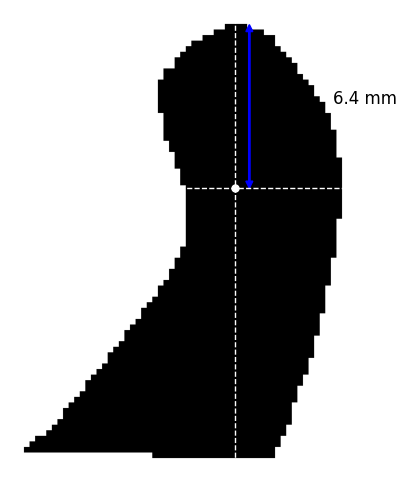

In [7]:
visualize_with_axes(scaled_mask, top_point[0], right_point[1], height=height)

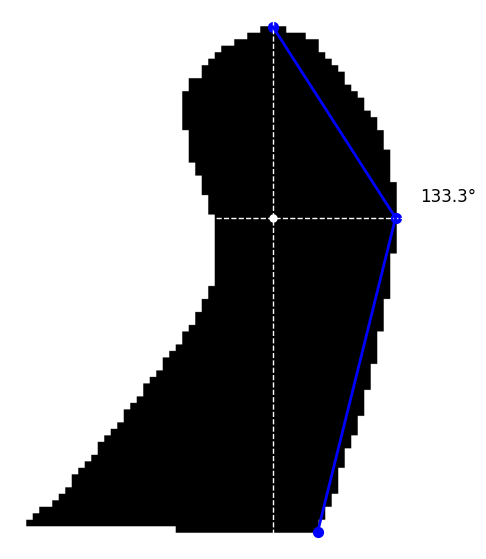

In [8]:
bot_x, bot_y = find_intersection(mask=scaled_mask, x_coord=top_point[0])
angle_back = calculate_angle(p1=top_point, p2=right_point, p3=(bot_x, bot_y))

visualize_with_angle(
    scaled_mask,
    top_point,
    right_point,
    (bot_x, bot_y),
    angle_back,
    is_back_angle=True
)

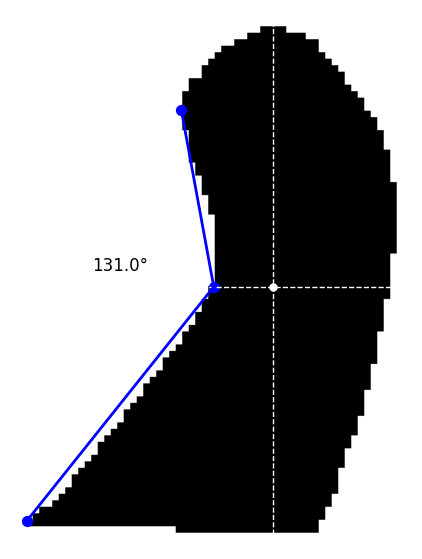

In [9]:
bottom_left_point = calculate_front_axes(scaled_mask)
angle_front = calculate_angle(p1=top_left_point, p2=left_point, p3=bottom_left_point)
# top_left_point and bottom_left_point
visualize_with_angle(
    scaled_mask,
    top_left_point,
    left_point,
    bottom_left_point,
    angle_front,
    is_back_angle=False,
    top_axis_point=top_point
)

In [25]:
from scipy.stats import skew, kurtosis
import pandas as pd
import numpy as np

# Создаём DataFrame из данных HU
data = {
    "HU": [
        -116.6, -79.14, -42.28, -5.42, 31.44, 68.3, 105.16, 142.02, 178.88, 215.74,
        252.6, 289.46, 326.32, 363.18, 400.04, 436.9, 473.76, 510.62, 547.48, 584.34,
        621.2, 658.06, 694.92, 731.78, 768.64, 805.5, 842.36, 879.22, 916.08, 952.94,
        989.8, 1026.66, 1063.52, 1100.38, 1137.24, 1174.1, 1210.96, 1247.82, 1284.68,
        1321.54, 1358.4, 1395.26, 1432.12, 1468.98, 1505.84, 1542.7, 1579.56, 1616.42,
        1653.28, 1690.14, 1727.0
    ],
    "count": [
        6, 11, 14, 36, 40, 73, 81, 103, 130, 162, 227, 232, 254, 312, 279, 319, 332,
        282, 294, 275, 268, 253, 250, 233, 200, 266, 284, 268, 314, 315, 371, 406,
        443, 503, 548, 536, 505, 459, 394, 380, 410, 411, 464, 464, 374, 308, 214,
        127, 61, 33, 0
    ]
}

df = pd.DataFrame(data)

# Расчёт статистик первого порядка, взвешенных по количеству пикселей (count)
weighted_mean = np.average(df["HU"], weights=df["count"])
weighted_variance = np.average((df["HU"] - weighted_mean) ** 2, weights=df["count"])
weighted_std = np.sqrt(weighted_variance)
weighted_median = df.loc[df.index.repeat(df["count"])].sort_values("HU")["HU"].median()
mode = df.loc[df["count"].idxmax(), "HU"]

# Коэффициент вариации (в %)
coeff_variation = (weighted_std / weighted_mean) * 100

weighted_stats = {
    "Среднее значение (HU)": weighted_mean,
    "Медиана (HU)": weighted_median,
    "Мода (HU)": mode,
    "Стандартное отклонение (HU)": weighted_std,
    "Дисперсия (HU)": weighted_variance,
    "Коэффициент вариации (%)": coeff_variation
}

# Создаём повторённый список значений HU по количеству пикселей (count)
expanded_values = np.repeat(df["HU"].values, df["count"].values)

# Расчёт асимметрии и эксцесса
skewness = skew(expanded_values)
kurt = kurtosis(expanded_values, fisher=True)  # Fisher=True -> эксцесс относительно нормального распределения

# Добавляем к статистикам
weighted_stats.update({
    "Асимметрия": skewness,
    "Эксцесс": kurt
})

for k, v in weighted_stats.items():
    print(f"{k}: {v:.4f}")

Среднее значение (HU): 950.6312
Медиана (HU): 1026.6600
Мода (HU): 1137.2400
Стандартное отклонение (HU): 419.0201
Дисперсия (HU): 175577.8810
Коэффициент вариации (%): 44.0781
Асимметрия: -0.3513
Эксцесс: -0.9673


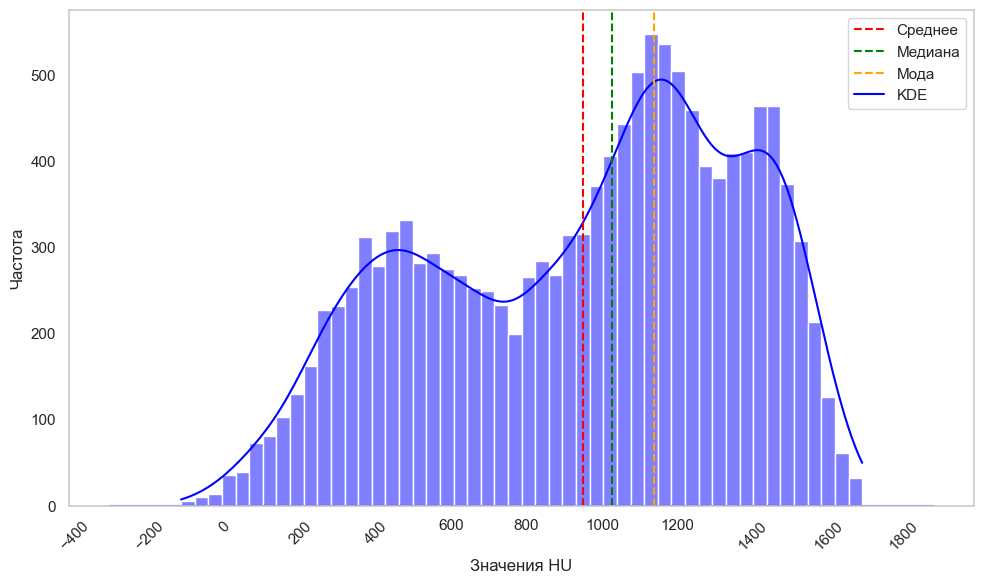

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Строим гистограмму
plt.figure(figsize=(10, 6))
sns.histplot(expanded_values, bins=50, kde=True, edgecolor="white", alpha=0.5, color='blue')

# Вертикальные линии для статистик
plt.axvline(weighted_stats["Среднее значение (HU)"], color='red', linestyle='--', label='Среднее')
plt.axvline(weighted_stats["Медиана (HU)"], color='green', linestyle='--', label='Медиана')
plt.axvline(weighted_stats["Мода (HU)"], color='orange', linestyle='--', label='Мода')
sns.kdeplot(expanded_values, color='blue', label='KDE')

# Подписи и оформление
plt.xlabel("Значения HU")
plt.ylabel("Частота")

# Настройка отображения меток оси X, чтобы они появлялись чаще
plt.xticks(rotation=45)  # Поворот меток оси X, чтобы они не перекрывались
plt.locator_params(axis='x', nbins=15)  # Указываем, сколько меток будет на оси X

# Убираем сетку
plt.grid(False)

# Легенда и отображение графика
plt.legend()
plt.tight_layout()
plt.savefig('histogram_with_kde.png', dpi=300)  # Сохраняем в PNG формате с разрешением 300 dpi

plt.show()

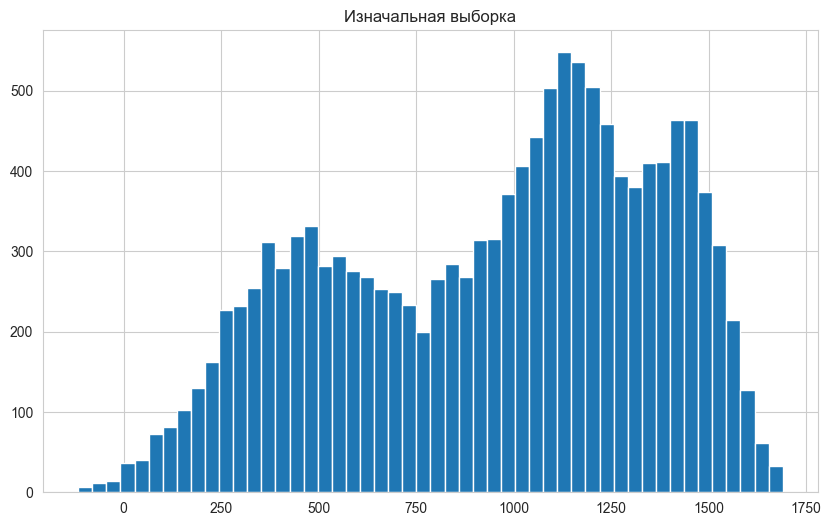

Рекомендую разделить на HU = 768.70


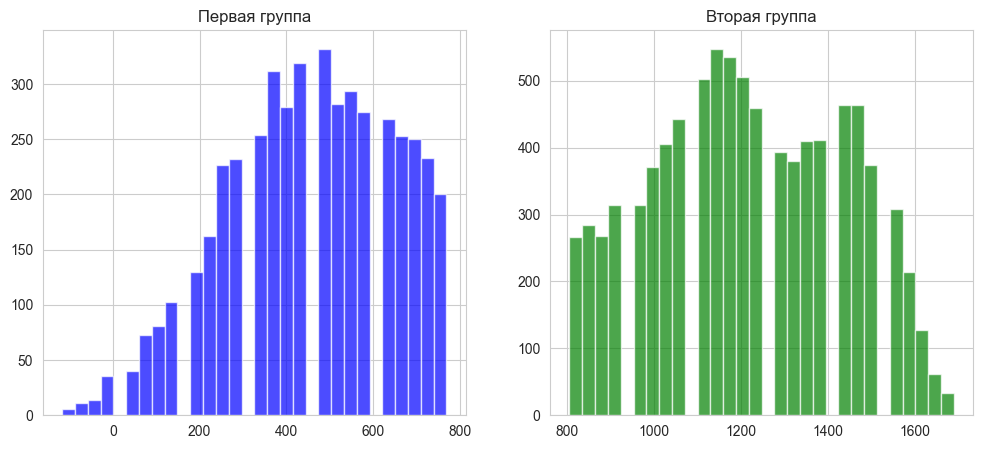

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Твои данные
data = {
    "HU": [
        -116.6, -79.14, -42.28, -5.42, 31.44, 68.3, 105.16, 142.02, 178.88, 215.74,
        252.6, 289.46, 326.32, 363.18, 400.04, 436.9, 473.76, 510.62, 547.48, 584.34,
        621.2, 658.06, 694.92, 731.78, 768.64, 805.5, 842.36, 879.22, 916.08, 952.94,
        989.8, 1026.66, 1063.52, 1100.38, 1137.24, 1174.1, 1210.96, 1247.82, 1284.68,
        1321.54, 1358.4, 1395.26, 1432.12, 1468.98, 1505.84, 1542.7, 1579.56, 1616.42,
        1653.28, 1690.14, 1727.0
    ],
    "count": [
        6, 11, 14, 36, 40, 73, 81, 103, 130, 162, 227, 232, 254, 312, 279, 319, 332,
        282, 294, 275, 268, 253, 250, 233, 200, 266, 284, 268, 314, 315, 371, 406,
        443, 503, 548, 536, 505, 459, 394, 380, 410, 411, 464, 464, 374, 308, 214,
        127, 61, 33, 0
    ]
}

# Восстановим "сырые" точки из гистограммы
hu_values = []
for hu, c in zip(data["HU"], data["count"]):
    hu_values += [hu] * c
hu_values = np.array(hu_values)

# Нарисуем гистограмму
plt.figure(figsize=(10,6))
plt.hist(hu_values, bins=50)
plt.title("Изначальная выборка")
plt.show()

# Найдем пики
hist, bin_edges = np.histogram(hu_values, bins=50)
peaks, _ = find_peaks(hist, distance=5)

# Найдем минимум между двумя пиками
if len(peaks) >= 2:
    # Пики нашлись
    first_peak = peaks[0]
    second_peak = peaks[1]
    # Минимум между ними
    valley_index = np.argmin(hist[first_peak:second_peak]) + first_peak
    split_value = (bin_edges[valley_index] + bin_edges[valley_index+1]) / 2
    print(f"Рекомендую разделить на HU = {split_value:.2f}")
else:
    print("Не удалось найти два пика автоматически.")

# Разделим
part1 = hu_values[hu_values <= split_value]
part2 = hu_values[hu_values > split_value]

# Нарисуем раздельно
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(part1, bins=30, color='blue', alpha=0.7)
plt.title("Первая группа")

plt.subplot(1,2,2)
plt.hist(part2, bins=30, color='green', alpha=0.7)
plt.title("Вторая группа")

plt.show()


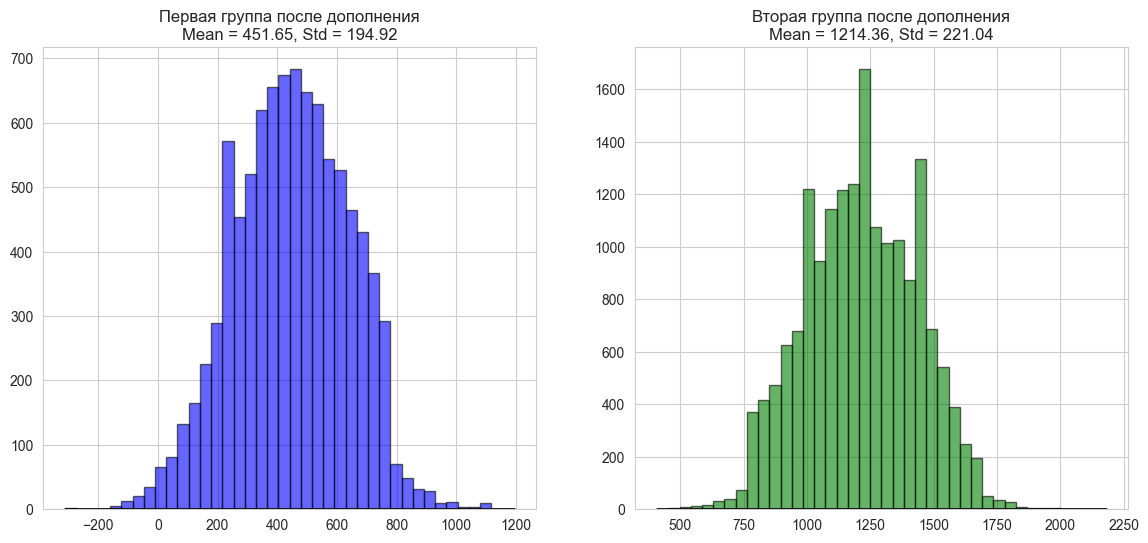

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# part1 и part2 уже есть
# допустим, у нас есть:
# part1 = np.array([...])
# part2 = np.array([...])

# Функция дополнения выборки
def augment_to_normal(data, multiplier=2):
    mu, std = np.mean(data), np.std(data)
    n_new = (multiplier - 1) * len(data)
    new_samples = np.random.normal(mu, std, n_new)
    return np.concatenate([data, new_samples])

# Дополняем обе части
part1_augmented = augment_to_normal(part1, multiplier=2)
part2_augmented = augment_to_normal(part2, multiplier=2)

# Проверяем графиками
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.hist(part1_augmented, bins=40, color='blue', alpha=0.6, edgecolor='black')
mu1, std1 = np.mean(part1_augmented), np.std(part1_augmented)
x1 = np.linspace(min(part1_augmented), max(part1_augmented), 100)
plt.plot(x1, norm.pdf(x1, mu1, std1), 'k', linewidth=2)
plt.title(f"Первая группа после дополнения\nMean = {mu1:.2f}, Std = {std1:.2f}")

plt.subplot(1,2,2)
plt.hist(part2_augmented, bins=40, color='green', alpha=0.6, edgecolor='black')
mu2, std2 = np.mean(part2_augmented), np.std(part2_augmented)
x2 = np.linspace(min(part2_augmented), max(part2_augmented), 100)
plt.plot(x2, norm.pdf(x2, mu2, std2), 'k', linewidth=2)
plt.title(f"Вторая группа после дополнения\nMean = {mu2:.2f}, Std = {std2:.2f}")

plt.show()


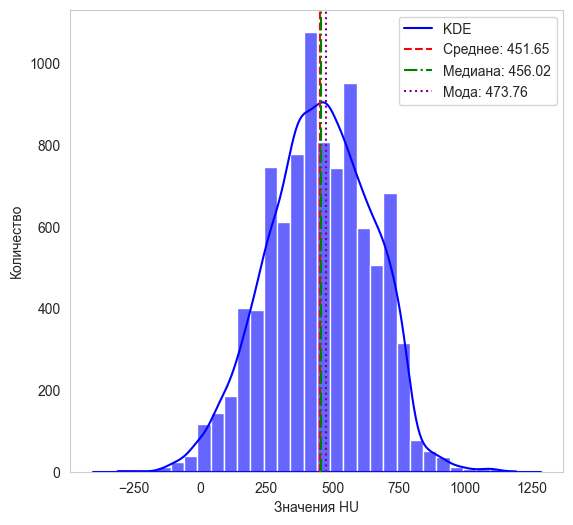

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.histplot(part1_augmented, bins=30, kde=True, color='blue', edgecolor='white', alpha=0.6)
sns.kdeplot(part1_augmented, color='blue', label='KDE')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Считаем среднее, медиану и моду
mean1 = np.mean(part1_augmented)
median1 = np.median(part1_augmented)
mode1 = stats.mode(part1_augmented, keepdims=False).mode  # В scipy 1.9+ нужно keepdims

# Добавляем линии
plt.axvline(mean1, color='red', linestyle='--', label=f'Среднее: {mean1:.2f}')
plt.axvline(median1, color='green', linestyle='-.', label=f'Медиана: {median1:.2f}')
plt.axvline(mode1, color='purple', linestyle=':', label=f'Мода: {mode1:.2f}')

plt.legend()
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.grid(False)
plt.xlabel("Значения HU")
plt.savefig('histogram_with_kde.png', dpi=300)  # Сохраняем в PNG формате с разрешением 300 dpi
plt.show()

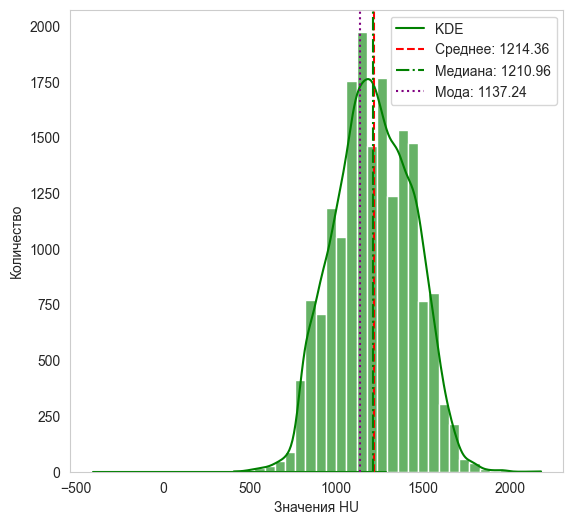

In [20]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.histplot(part2_augmented, bins=30, kde=True, color='green', edgecolor='white', alpha=0.6)

sns.kdeplot(part1_augmented, color='green', label='KDE')
# Считаем среднее, медиану и моду
mean1 = np.mean(part2_augmented)
median1 = np.median(part2_augmented)
mode1 = stats.mode(part2_augmented, keepdims=False).mode  # В scipy 1.9+ нужно keepdims

# Добавляем линии
plt.axvline(mean1, color='red', linestyle='--', label=f'Среднее: {mean1:.2f}')
plt.axvline(median1, color='green', linestyle='-.', label=f'Медиана: {median1:.2f}')
plt.axvline(mode1, color='purple', linestyle=':', label=f'Мода: {mode1:.2f}')
plt.legend()
plt.grid(False)
plt.ylabel('Количество')
plt.xlabel("Значения HU")
plt.savefig('histogram_with_kde.png', dpi=300)  # Сохраняем в PNG формате с разрешением 300 dpi

plt.show()